In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
customers = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\customers.csv")
geolocation = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\geolocation.csv")
items = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\items.csv")
order_items = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\order_items.csv")
order_payments = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\order_payments.csv")
order_reviews = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\order_reviews.csv")
orders = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\orders.csv")
products = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\products.csv")
sellers = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\sellers.csv")

print("All datasets loaded succesfully")

All datasets loaded succesfully


C:\Users\DELL\AppData\Local\Temp\ipykernel_3688\4075108910.py:7: DtypeWarning: Columns (0,1,2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv(r"C:\Users\DELL\Documents\Portfolio Project\Olist_Cleaned\orders.csv")


In [3]:

print("Dataset shapes (rows, columns):")
print(f"Customers:      {customers.shape}")
print(f"Orders:         {orders.shape}")
print(f"Order Items:    {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews:  {order_reviews.shape}")
print(f"Products:       {products.shape}")
print(f"Sellers:        {sellers.shape}")
print(f"Geolocation:    {geolocation.shape}")

Dataset shapes (rows, columns):
Customers:      (99441, 5)
Orders:         (1048575, 8)
Order Items:    (112650, 7)
Order Payments: (103886, 5)
Order Reviews:  (99224, 7)
Products:       (32951, 9)
Sellers:        (3095, 4)
Geolocation:    (1000163, 5)


In [4]:
print("MISSING VALUES PER DATASET:")
print("=" * 50)

datasets = {
    'Customers': customers,
    'Orders': orders,
    'Order Items': order_items,
    'Order Payments': order_payments,
    'Order Reviews': order_reviews,
    'Products': products,
    'Sellers': sellers,
    'Geolocation': geolocation
}

for name, df in datasets.items():
    missing = df.isnull().sum().sum()  # total missing values
    print(f"{name}: {missing:,} missing values")

MISSING VALUES PER DATASET:
Customers: 0 missing values
Orders: 7,597,980 missing values
Order Items: 0 missing values
Order Payments: 0 missing values
Order Reviews: 146,260 missing values
Products: 2,448 missing values
Sellers: 0 missing values
Geolocation: 0 missing values


In [5]:
print(f"Dataset Information: {customers.describe()}")

Dataset Information:        customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000


In [19]:
print(f"Orders before cleaning: {orders.shape[0]:,} rows")
orders = orders.drop_duplicates(subset='order_id', keep='first')
print(f"Orders after cleaning:  {orders.shape[0]:,} rows")

Orders before cleaning: 99,442 rows
Orders after cleaning:  99,442 rows


In [20]:
orders = orders.drop_duplicates(subset='order_id', keep='first').copy()

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders.loc[:, col] = pd.to_datetime(orders[col], format='mixed', errors='coerce')

print("Date columns converted successfully!")
print("\nUpdated data types:")
print(orders[date_columns].dtypes)

Date columns converted successfully!

Updated data types:
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [21]:
# Filter delivered orders only

delivered_orders = orders[orders['order_status'] == 'Delivered'].copy()

print(f"Total delivered orders: {len(delivered_orders):,}")

# Merge orders with payments

revenue_df = delivered_orders.merge(order_payments, on='order_id', how='inner')

# Calculate total revenue
total_revenue = revenue_df['payment_value'].sum()
avg_order_value = revenue_df.groupby('order_id')['payment_value'].sum().mean()

print(f"Total Revenue:     R${total_revenue:,.2f}")
print(f"Avg Order Value:   R${avg_order_value:,.2f}")

Total delivered orders: 96,478
Total Revenue:     R$15,422,461.77
Avg Order Value:   R$159.86


In [9]:
# Extract year and month from the purchase timestamp
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(
    delivered_orders['order_purchase_timestamp']
)

delivered_orders['month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')

# Merge with payments
monthly_revenue = delivered_orders.merge(order_payments, on='order_id', how='inner')

# Group by month and sum revenue
monthly_revenue = monthly_revenue.groupby('month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

print(monthly_revenue.head(10))

     month    revenue
0  2016-10   46566.71
1  2016-12      19.62
2  2017-01  127545.67
3  2017-02  271298.65
4  2017-03  414369.39
5  2017-04  390952.18
6  2017-05  567066.73
7  2017-06  490225.60
8  2017-07  566403.93
9  2017-08  646000.61


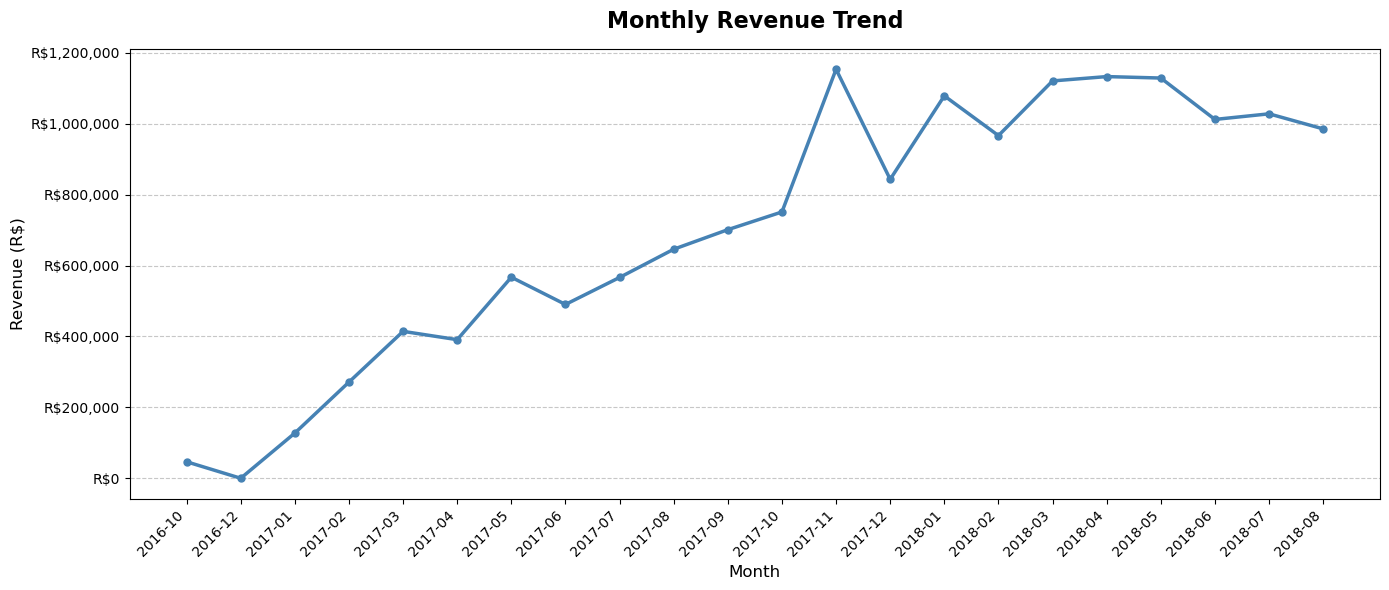

In [22]:
plt.figure(figsize=(14, 6))
# x = months on horizontal axis
# y = revenue on vertical axis
plt.plot(monthly_revenue['month'], 
         monthly_revenue['revenue'], 
         color='steelblue', 
         linewidth=2.5,
         marker='o',        
         markersize=5)

plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

plt.tight_layout()
plt.show()

In [23]:
# Correct category revenue calculation
# Only need order_items + products + orders
# No need for order_payments for category level analysis

category_revenue = delivered_orders.merge(order_items, on='order_id', how='inner') \
                                   .merge(products, on='product_id', how='inner')

# Calculate revenue as price + freight_value
category_revenue['item_revenue'] = category_revenue['price'] + \
                                    category_revenue['freight_value']

# Group by category
category_revenue = category_revenue.groupby('product_category_name').agg(
    total_revenue=('item_revenue', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Round to 2 decimal places to match SQL
category_revenue['total_revenue'] = category_revenue['total_revenue'].round(2)

# Sort and take top 10
category_revenue = category_revenue.sort_values('total_revenue', ascending=False).head(10)

print(category_revenue)

     product_category_name  total_revenue  total_orders
11            Beleza Saude     1412089.53          8647
66      Relogios Presentes     1264333.12          5495
13         Cama Mesa Banho     1225209.26          9272
32           Esporte Lazer     1118256.91          7530
44  Informatica Acessorios     1032723.77          6530
54        Moveis Decoracao      880329.92          6307
72   Utilidades Domesticas      758392.25          5743
26              Cool Stuff      691680.89          3559
8               Automotivo      669454.75          3810
40      Ferramentas Jardim      567145.68          3448


C:\Users\DELL\AppData\Local\Temp\ipykernel_3688\2438177580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue,


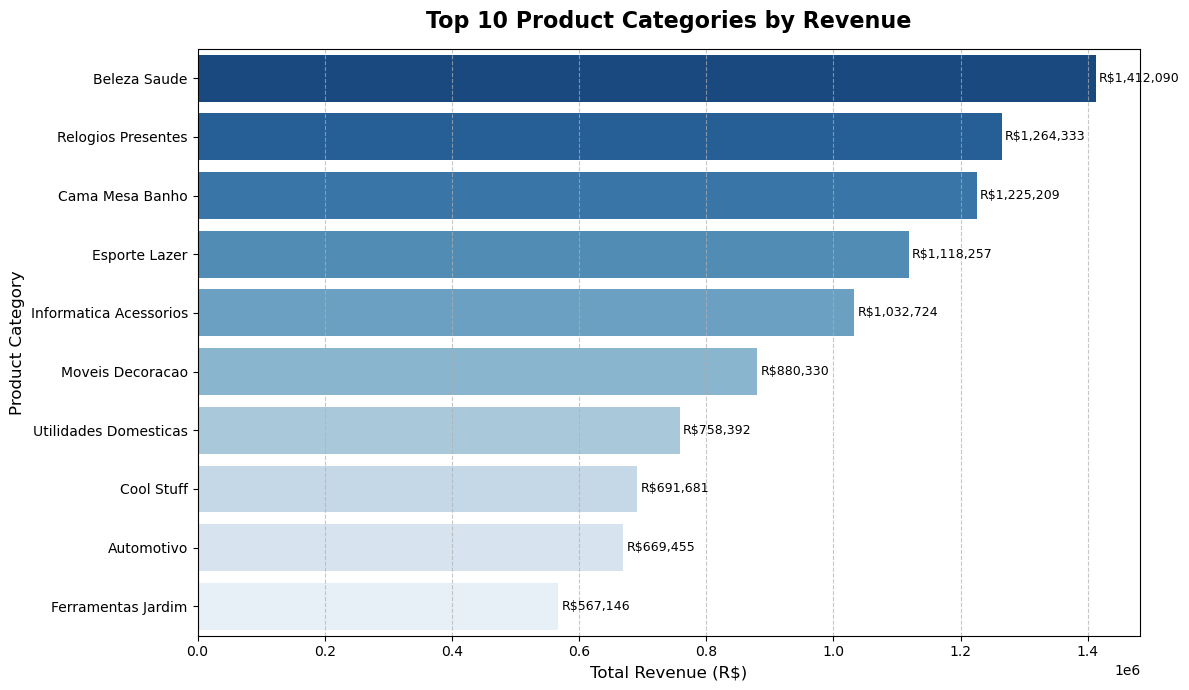

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(data=category_revenue,
            x='total_revenue',
            y='product_category_name',
            palette='Blues_r')

# Add value labels on each bar
for i, value in enumerate(category_revenue['total_revenue']):
    plt.text(value + 5000, i, f'R${value:,.0f}',
             va='center', fontsize=9)

plt.title('Top 10 Product Categories by Revenue',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
# Merge delivered orders with customers to get state info
# Then count orders per state

customers_state = delivered_orders.merge(customers, on='customer_id', how='inner')

state_orders = customers_state.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Sort by total orders descending
state_orders = state_orders.sort_values('total_orders', ascending=False).head(10)

print(state_orders)

   customer_state  total_customers  total_orders
25             SP            39156         40501
18             RJ            11917         12350
10             MG            11001         11354
22             RS             5168          5345
17             PR             4769          4923
23             SC             3449          3546
4              BA             3158          3256
6              DF             2019          2080
7              ES             1928          1995
8              GO             1895          1957


C:\Users\DELL\AppData\Local\Temp\ipykernel_3688\2438177580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue,


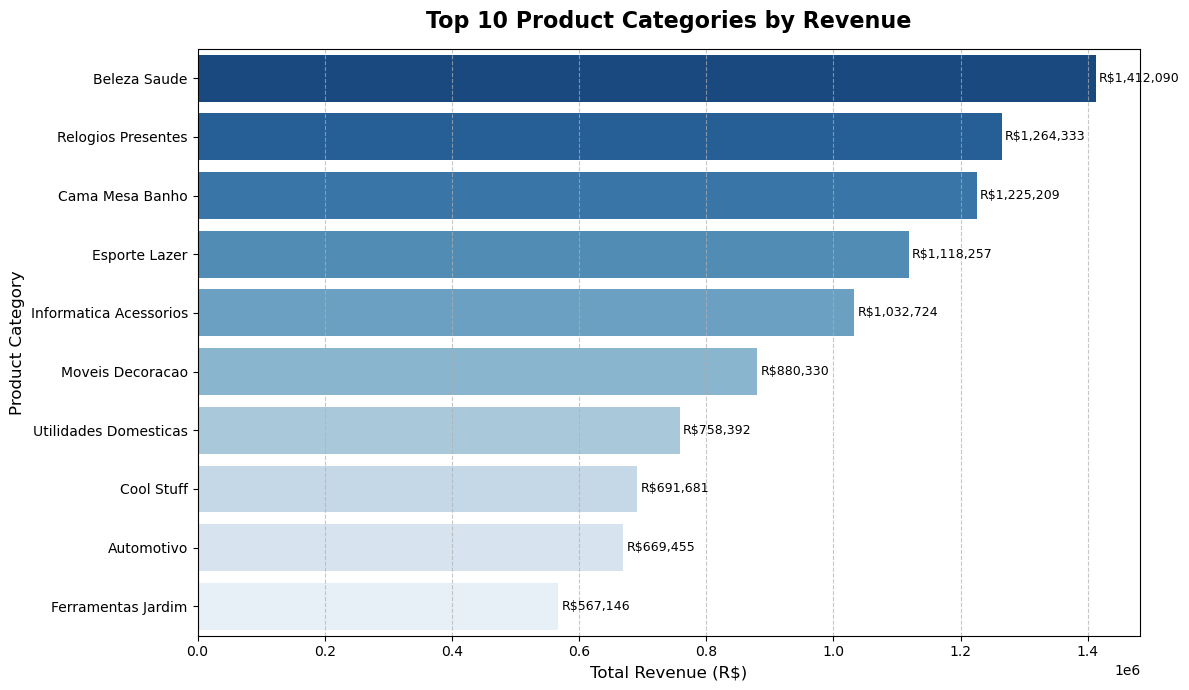

In [26]:
plt.figure(figsize=(12, 7))

sns.barplot(data=category_revenue,
            x='total_revenue',
            y='product_category_name',
            palette='Blues_r')

# Add value labels on each bar
for i, value in enumerate(category_revenue['total_revenue']):
    plt.text(value + 5000, i, f'R${value:,.0f}',
             va='center', fontsize=9)

plt.title('Top 10 Product Categories by Revenue',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
# Merge delivered orders with customers to get state info
# Then count orders per state

customers_state = delivered_orders.merge(customers, on='customer_id', how='inner')

state_orders = customers_state.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Sort by total orders descending
state_orders = state_orders.sort_values('total_orders', ascending=False).head(10)

print(state_orders)

   customer_state  total_customers  total_orders
25             SP            39156         40501
18             RJ            11917         12350
10             MG            11001         11354
22             RS             5168          5345
17             PR             4769          4923
23             SC             3449          3546
4              BA             3158          3256
6              DF             2019          2080
7              ES             1928          1995
8              GO             1895          1957


C:\Users\DELL\AppData\Local\Temp\ipykernel_3688\3599622974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_orders,


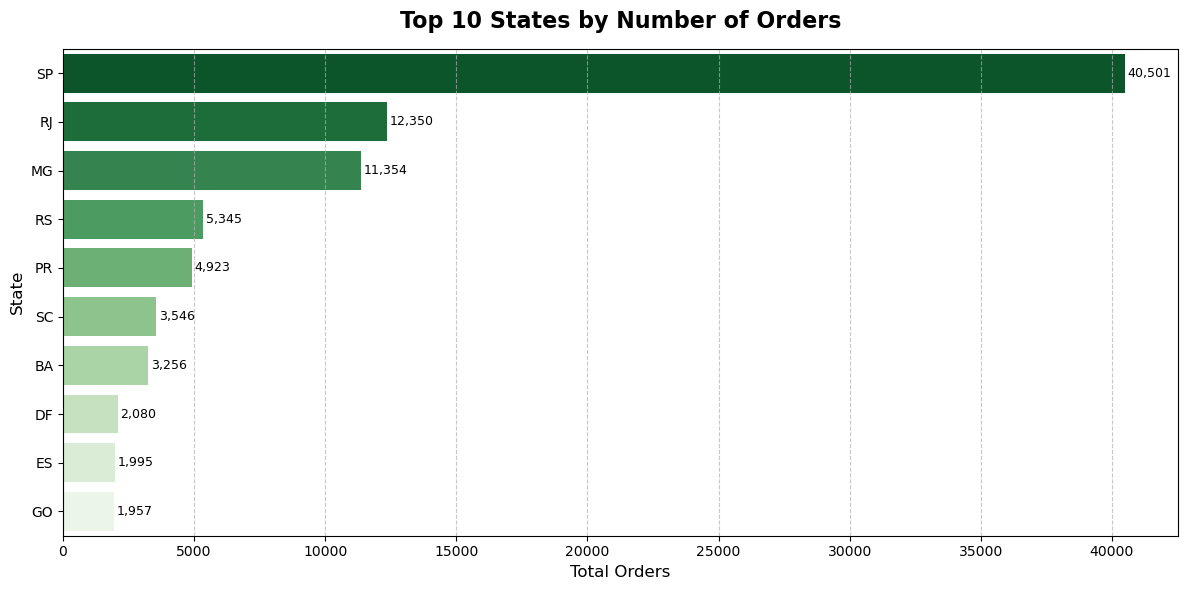

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(data=state_orders,
            x='total_orders',
            y='customer_state',
            palette='Greens_r')

# Add value labels
for i, value in enumerate(state_orders['total_orders']):
    plt.text(value + 100, i, f'{value:,}',
             va='center', fontsize=9)

plt.title('Top 10 States by Number of Orders',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
# Group by payment type
payment_analysis = order_payments.groupby('payment_type').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()

payment_analysis['total_revenue'] = payment_analysis['total_revenue'].round(2)
payment_analysis = payment_analysis.sort_values('total_orders', ascending=False)

print(payment_analysis)

  payment_type  total_orders  total_revenue
1  credit_card         76505    12542084.19
0       boleto         19784     2869361.27
4      voucher          3866      379436.87
2   debit_card          1528      217989.79
3  not_defined             3           0.00


C:\Users\DELL\AppData\Local\Temp\ipykernel_3688\1595290295.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_analysis,


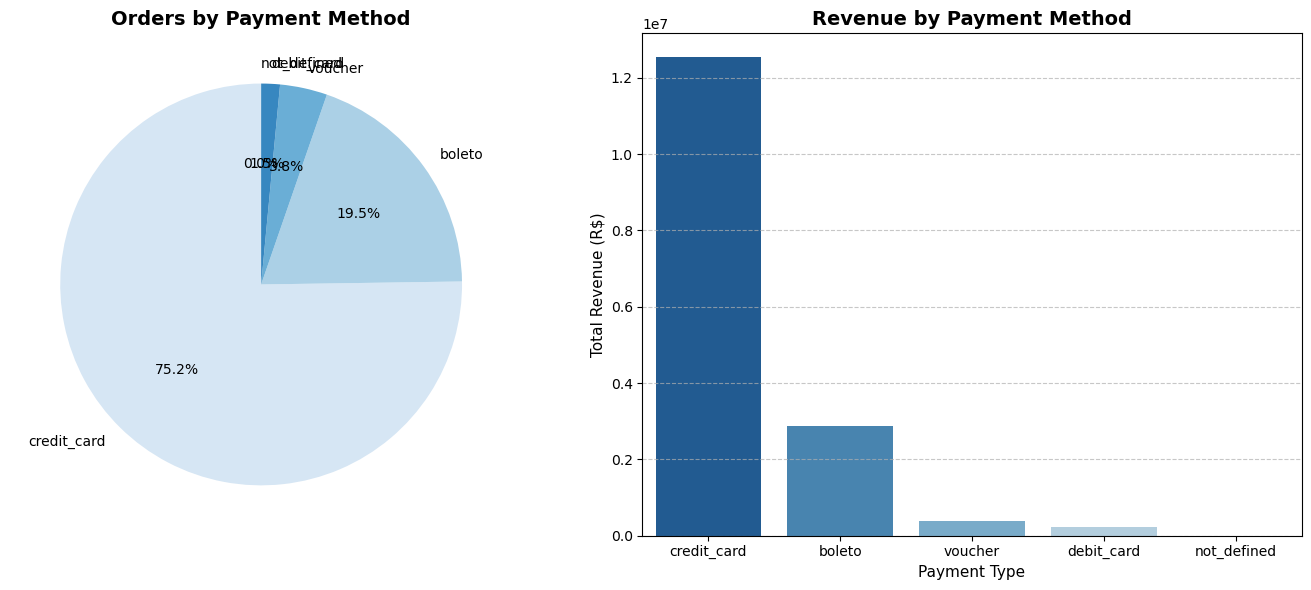

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Orders by payment type (pie chart)
ax1.pie(payment_analysis['total_orders'],
        labels=payment_analysis['payment_type'],
        autopct='%1.1f%%',
        colors=sns.color_palette('Blues', len(payment_analysis)),
        startangle=90)
ax1.set_title('Orders by Payment Method',
              fontsize=14, fontweight='bold')

# Chart 2 — Revenue by payment type (bar chart)
sns.barplot(data=payment_analysis,
            x='payment_type',
            y='total_revenue',
            palette='Blues_r',
            ax=ax2)
ax2.set_title('Revenue by Payment Method',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Payment Type', fontsize=11)
ax2.set_ylabel('Total Revenue (R$)', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [32]:
# Convert date columns to datetime explicitly after merge
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(
    delivered_orders['order_delivered_customer_date'], errors='coerce')
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(
    delivered_orders['order_purchase_timestamp'], errors='coerce')
delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(
    delivered_orders['order_estimated_delivery_date'], errors='coerce')

# Now calculate delivery days
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_purchase_timestamp']
).dt.days

# Remove negative or null delivery days
delivered_orders = delivered_orders[
    delivered_orders['delivery_days'].notna() & 
    (delivered_orders['delivery_days'] > 0)
].copy()

# Summary statistics
print("DELIVERY TIME ANALYSIS:")
print(f"Average delivery days: {delivered_orders['delivery_days'].mean():.1f}")
print(f"Fastest delivery:      {delivered_orders['delivery_days'].min()} days")
print(f"Slowest delivery:      {delivered_orders['delivery_days'].max()} days")
print(f"Median delivery:       {delivered_orders['delivery_days'].median():.1f} days")

DELIVERY TIME ANALYSIS:
Average delivery days: 12.1
Fastest delivery:      1.0 days
Slowest delivery:      209.0 days
Median delivery:       10.0 days


In [33]:
# Flag late orders
delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date'] > 
    delivered_orders['order_estimated_delivery_date']
)

late_orders = delivered_orders['is_late'].sum()
on_time_orders = (~delivered_orders['is_late']).sum()
total = len(delivered_orders)

print(f"Total orders:    {total:,}")
print(f"Late orders:     {late_orders:,} ({late_orders/total*100:.1f}%)")
print(f"On time orders:  {on_time_orders:,} ({on_time_orders/total*100:.1f}%)")

Total orders:    96,457
Late orders:     7,826 (8.1%)
On time orders:  88,631 (91.9%)


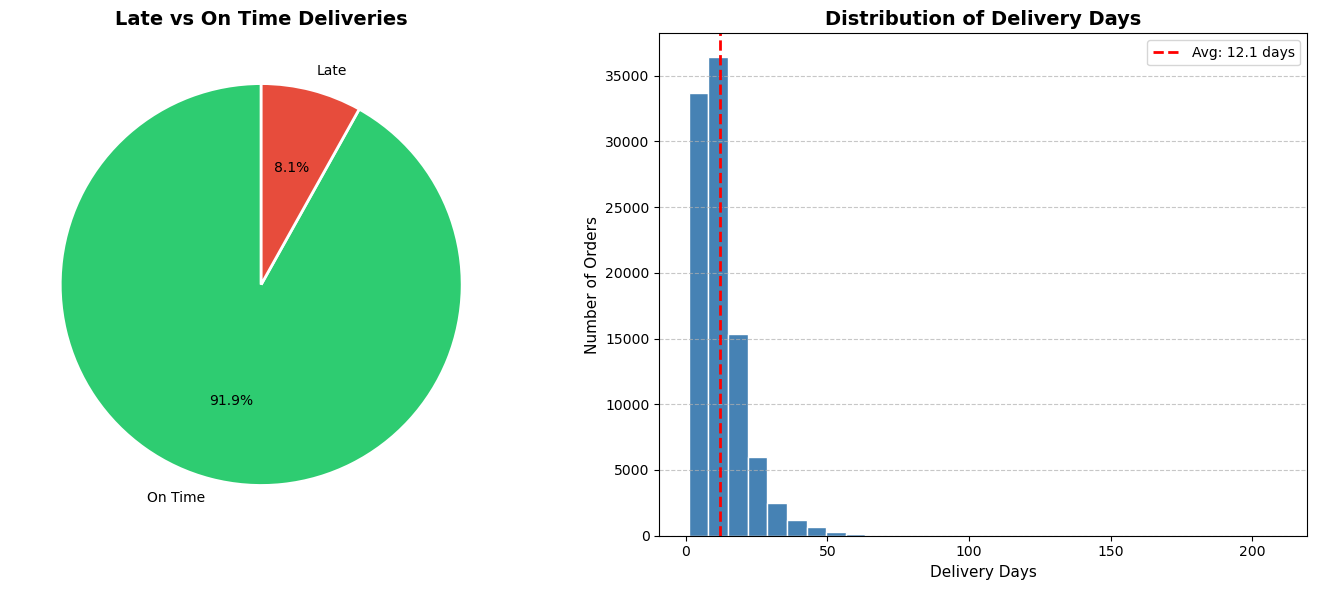

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Late vs On Time pie chart
labels = ['On Time', 'Late']
sizes = [on_time_orders, late_orders]
colors = ['#2ecc71', '#e74c3c']

ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Late vs On Time Deliveries',
              fontsize=14, fontweight='bold')

# Chart 2 — Delivery days distribution histogram
ax2.hist(delivered_orders['delivery_days'].dropna(),
         bins=30, color='steelblue', edgecolor='white')
ax2.axvline(delivered_orders['delivery_days'].mean(),
            color='red', linestyle='--', linewidth=2,
            label=f"Avg: {delivered_orders['delivery_days'].mean():.1f} days")
ax2.set_title('Distribution of Delivery Days',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Delivery Days', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [35]:
# Merge delivered orders with customers to get state
state_delivery = delivered_orders.merge(customers, on='customer_id', how='inner')

# Group by state and calculate average delivery days
state_delivery = state_delivery.groupby('customer_state').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Round and sort by worst delivery time
state_delivery['avg_delivery_days'] = state_delivery['avg_delivery_days'].round(1)
state_delivery = state_delivery.sort_values('avg_delivery_days', ascending=False).head(10)

print(state_delivery)

   customer_state  avg_delivery_days  total_orders
21             RR               29.0            41
3              AP               26.7            67
2              AM               26.0           145
1              AL               24.0           397
13             PA               23.3           946
9              MA               21.1           717
24             SE               21.0           335
5              CE               20.8          1279
0              AC               20.6            80
14             PB               20.0           517


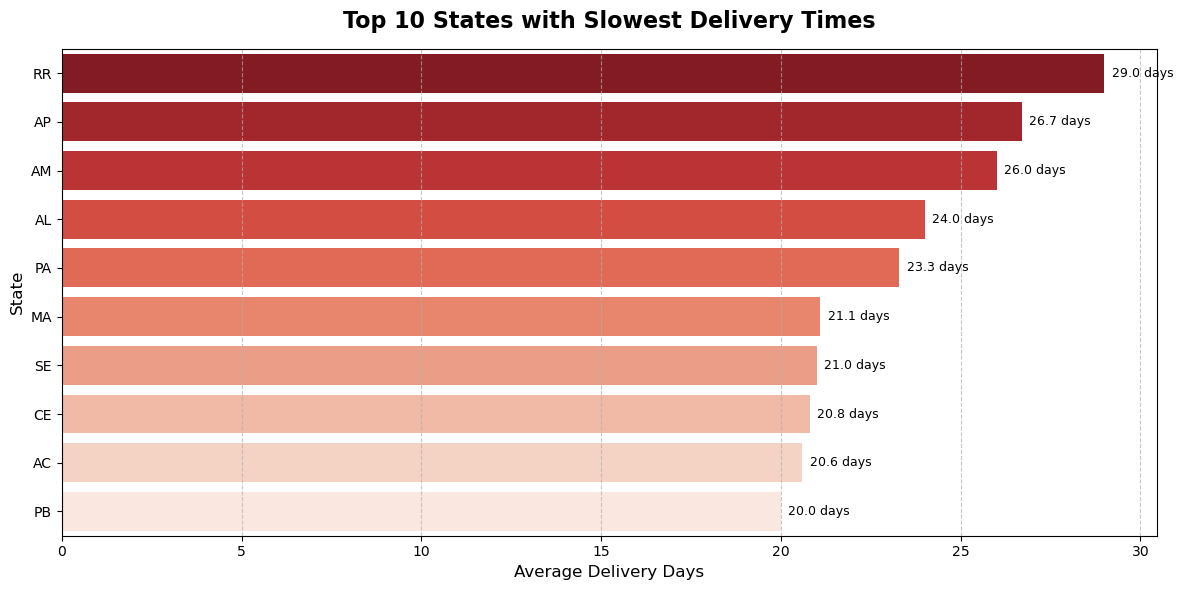

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(data=state_delivery,
            x='avg_delivery_days',
            y='customer_state',
            hue='customer_state',
            legend=False,
            palette='Reds_r')

# Add value labels
for i, value in enumerate(state_delivery['avg_delivery_days']):
    plt.text(value + 0.2, i, f'{value} days',
             va='center', fontsize=9)

plt.title('Top 10 States with Slowest Delivery Times',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Delivery Days', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
# Merge reviews with delivered orders
reviews_df = delivered_orders.merge(order_reviews, on='order_id', how='inner')

# Overall review score distribution
score_distribution = reviews_df['review_score'].value_counts().sort_index()

print("REVIEW SCORE DISTRIBUTION:")
print(score_distribution)
print(f"\nOverall Average Score: {reviews_df['review_score'].mean():.2f}")
print(f"Total Reviews: {len(reviews_df):,}")

REVIEW SCORE DISTRIBUTION:
review_score
1     9404
2     2941
3     7959
4    18985
5    57051
Name: count, dtype: int64

Overall Average Score: 4.16
Total Reviews: 96,340


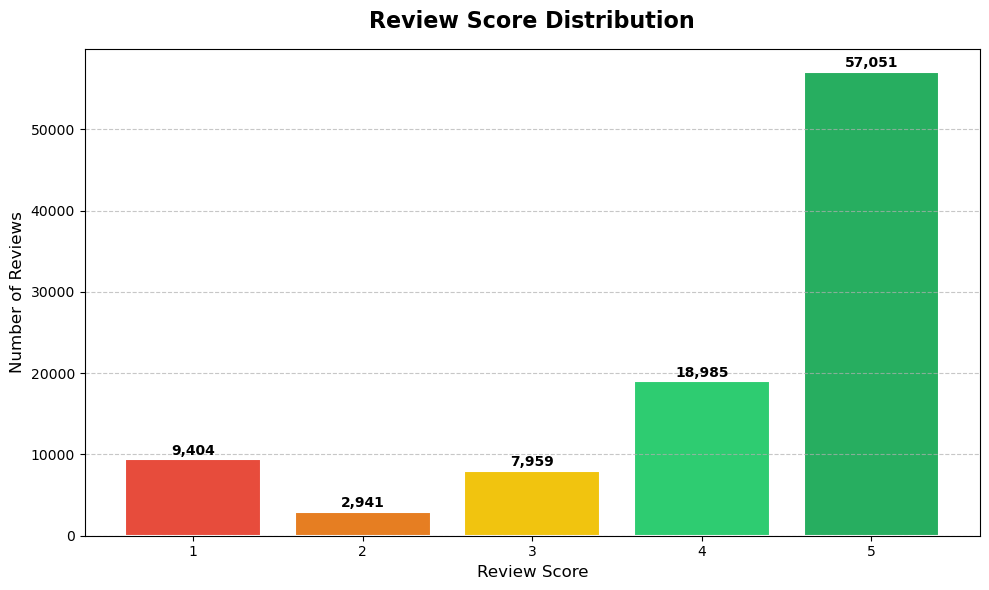

In [38]:
plt.figure(figsize=(10, 6))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = plt.bar(score_distribution.index, 
               score_distribution.values,
               color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, score_distribution.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 200,
             f'{value:,}', ha='center', 
             va='bottom', fontsize=10, fontweight='bold')

plt.title('Review Score Distribution',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:

reviews_df['is_late'] = (
    reviews_df['order_delivered_customer_date'] > 
    reviews_df['order_estimated_delivery_date']
)

# Compare average review score for late vs on time
late_review = reviews_df.groupby('is_late')['review_score'].agg(
    avg_score='mean',
    total_reviews='count'
).reset_index()

late_review['delivery_status'] = late_review['is_late'].map(
    {True: 'Late', False: 'On Time'}
)

print(late_review[['delivery_status', 'avg_score', 'total_reviews']])

  delivery_status  avg_score  total_reviews
0         On Time   4.293727          88640
1            Late   2.566494           7700


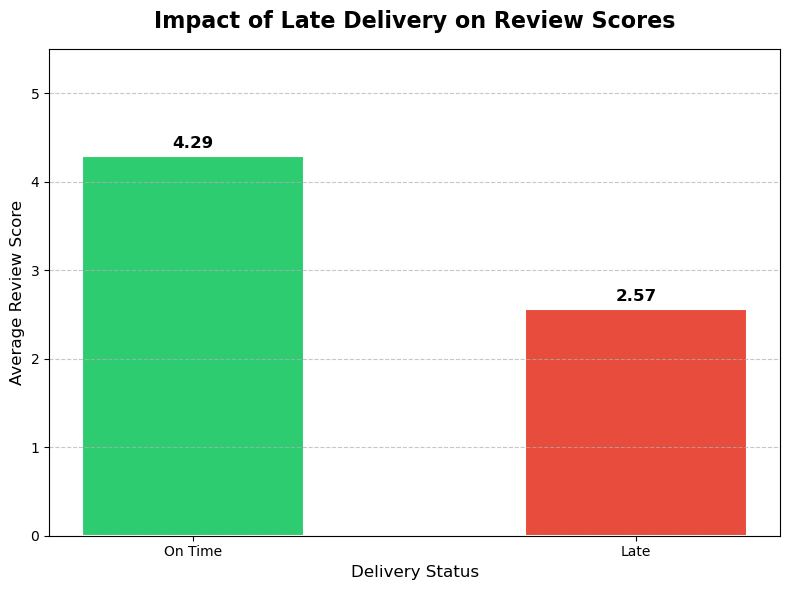

In [40]:
plt.figure(figsize=(8, 6))

colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(late_review['delivery_status'],
               late_review['avg_score'],
               color=colors, edgecolor='white',
               linewidth=1.5, width=0.5)

# Add value labels
for bar, value in zip(bars, late_review['avg_score']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{value:.2f}', ha='center',
             va='bottom', fontsize=12, fontweight='bold')

plt.title('Impact of Late Delivery on Review Scores',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
# Merge reviews with order items and products
category_ratings = reviews_df.merge(order_items, on='order_id', how='inner') \
                              .merge(products, on='product_id', how='inner')

# Group by category
category_ratings = category_ratings.groupby('product_category_name').agg(
    avg_rating=('review_score', 'mean'),
    total_reviews=('review_id', 'count')
).reset_index()

# Filter categories with more than 50 reviews
category_ratings = category_ratings[category_ratings['total_reviews'] > 50]
category_ratings['avg_rating'] = category_ratings['avg_rating'].round(2)

# Bottom 10
lowest_rated = category_ratings.sort_values('avg_rating').head(10)
print("LOWEST RATED CATEGORIES:")
print(lowest_rated)

LOWEST RATED CATEGORIES:
               product_category_name  avg_rating  total_reviews
55                 Moveis Escritorio        3.52           1664
38           Fashion Roupa Masculina        3.76            124
71                    Telefonia Fixa        3.76            253
7                              Audio        3.83            359
14                     Casa Conforto        3.85            430
13                   Cama Mesa Banho        3.92          10978
57                       Moveis Sala        3.94            494
54                  Moveis Decoracao        3.95           8158
16                   Casa Construcao        3.96            593
25  Construcao Ferramentas Seguranca        3.97            182


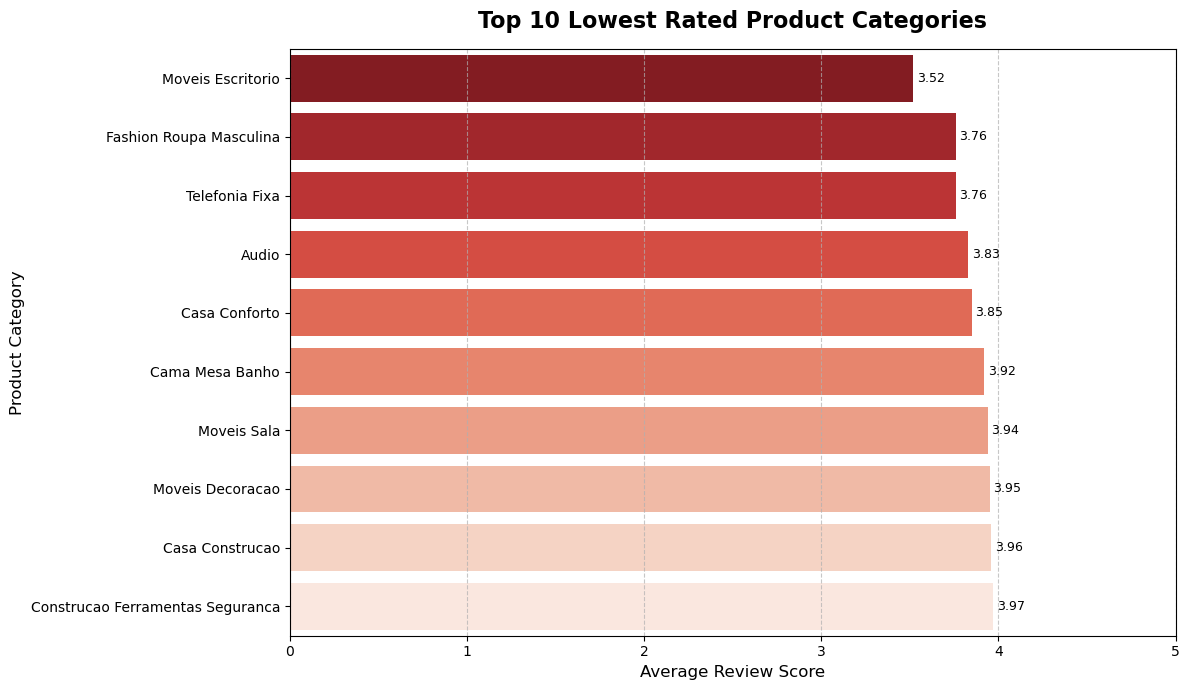

In [42]:
plt.figure(figsize=(12, 7))

sns.barplot(data=lowest_rated,
            x='avg_rating',
            y='product_category_name',
            hue='product_category_name',
            legend=False,
            palette='Reds_r')

# Add value labels
for i, value in enumerate(lowest_rated['avg_rating']):
    plt.text(value + 0.02, i, f'{value}',
             va='center', fontsize=9)

plt.title('Top 10 Lowest Rated Product Categories',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Review Score', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()